In [218]:
import sys
#!{sys.executable} -m pip install lpips

import torch                        #The main library for deep learning
import torch.nn as nn               #Neural Network module in PyTorch
from torch.nn import AdaptiveAvgPool2d
import torch.nn.functional as F
import torch.optim as optim         #contains optimizers for training neural networks(SGD,Adam)
from torchvision import datasets    #torchvision is PyTorch library for vision tasks tandard datasets (MNIST, CIFAR10, ImageNet...) , 
from torchvision import datasets, transforms #Preprocessing (resize, normalize, convert to tensor, etc.)
from torchvision.models import inception_v3
from torch.utils.data import DataLoader      #Loads dataset in batches and allows shuffling
from torch.utils.data import Subset          #selects a subset of the dataset, useful for debugging or small experiments.

import numpy as np
import matplotlib.pyplot as plt

from pytorch_msssim import ms_ssim 
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import lpips 
import scipy.linalg


In [219]:
# --------------------
# Config
# --------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
batch_size = 8
epochs = 200
lr = 0.0002
img_size = 256

Using device: cpu


In [220]:
# --------------------
# Dataset (MNIST [28x28] → 256x256x3)
# --------------------
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),      #[256, 256]
    transforms.Grayscale(num_output_channels=3),  #[3, 256, 256]
    transforms.ToTensor(),                        #[3, 256, 256], values 0–1
    transforms.Normalize((0.5,), (0.5,))          #[3, 256, 256], values -1 to 1    Mean Variance
])

In [221]:

# ----------------
# Load full MNIST datasets
# ----------------
train_data = datasets.MNIST("./data", train=True, download=True, transform=transform)  # Each item is a tuple (image, label)
val_data   = datasets.MNIST("./data", train=False, download=True, transform=transform)

# ----------------
# Create small subset (first 10 images) for both train and val
# ----------------
small_train_data = Subset(train_data, range(10))
small_val_data   = Subset(val_data, range(10))

# ----------------
# DataLoaders
# ----------------
batch_size = 5
train_loader = DataLoader(small_train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(small_val_data, batch_size=batch_size, shuffle=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Image size: torch.Size([3, 256, 256])
Image size: (256, 256, 3)


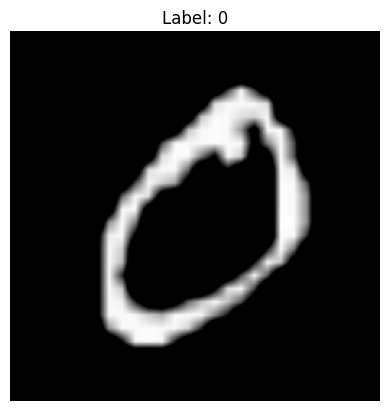

In [222]:
def ShowSmple():
    # img: Tensor [C, H, W] → convert to [H, W, C] for plotting

    img, label = train_data[1]  # first image  ([3, 256, 256])
    print("Image size:", img.shape) 
    img_np = img.permute(1, 2, 0).numpy()
    print("Image size:", img_np.shape) 
    # ----------------
    # Show
    # ----------------
   
    plt.imshow(img_np)
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

ShowSmple()

In [223]:

# --------------------
# Dense Block
# --------------------
class DenseBlock(nn.Module):
    def __init__(self, in_channels, growth_rate=32, n_layers=4, dropout=False):
        super().__init__()
        self.layers = nn.ModuleList()
        self.dropout = dropout
        for i in range(n_layers):
            self.layers.append(nn.Conv2d(
                in_channels + i * growth_rate, growth_rate, kernel_size=3, padding=1))
            self.layers.append(nn.BatchNorm2d(growth_rate))
            self.layers.append(nn.ReLU(inplace=True))
            if dropout:
                self.layers.append(nn.Dropout(0.5))

    def forward(self, x):
        features = [x]
        print("DenseBlock",x.shape)
        for i in range(0, len(self.layers), 4 if self.dropout else 3):
            out = self.layers[i](torch.cat(features, dim=1))
            out = self.layers[i+1](out)
            out = self.layers[i+2](out)
            if self.dropout:
                out = self.layers[i+3](out)
            features.append(out)
        return torch.cat(features, dim=1)


In [224]:
# --------------------
# Encoder Blocks
# --------------------
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, growth_rate=32, dropout=False):
        super().__init__()
        self.dense = DenseBlock(in_channels, growth_rate, n_layers=3, dropout=dropout)
        # Reduce channels to out_channels after dense concatenation
        self.conv1x1 = nn.Conv2d(in_channels + 3*growth_rate, out_channels, kernel_size=1)
        self.downsample = nn.Conv2d(out_channels, out_channels, 4, 2, 1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.dense(x)
        x = self.conv1x1(x)
        x = self.downsample(x)
        print("EncoderBlock",x.shape)
        return self.relu(x)

In [225]:
# --------------------
# Decoder Blocks
# --------------------
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, growth_rate=32, dropout=False):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1)
        self.dense = DenseBlock(out_channels, growth_rate, n_layers=3, dropout=dropout)
        self.conv1x1 = nn.Conv2d(out_channels + 3*growth_rate, out_channels, kernel_size=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.up(x)
        x = self.dense(x)
        x = self.conv1x1(x)
        print("DecoderBlock",x.shape)
        return self.relu(x)


In [226]:
# --------------------
# Dense-UNet Generator (7 encoder blocks)
# --------------------
class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        # Encoder
        self.e1 = EncoderBlock(in_channels, 64)
        self.e2 = EncoderBlock(64, 128)
        self.e3 = EncoderBlock(128, 256)
        self.e4 = EncoderBlock(256, 512)
        self.e5 = EncoderBlock(512, 512)
        self.e6 = EncoderBlock(512, 512)
        self.e7 = EncoderBlock(512, 512, dropout=True)

        # Decoder
        self.d1 = DecoderBlock(512, 512, dropout=True)
        self.d2 = DecoderBlock(512+512, 512, dropout=True)  # skip connection
        self.d3 = DecoderBlock(512+512, 512, dropout=True)
        self.d4 = DecoderBlock(512+512, 256)
        self.d5 = DecoderBlock(256+256, 128)
        self.d6 = DecoderBlock(128+128, 64)

        # Final output
        self.final = nn.ConvTranspose2d(64+64, out_channels, 4, 2, 1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        # Encoder
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        e5 = self.e5(e4)
        e6 = self.e6(e5)
        e7 = self.e7(e6)

        # Decoder with skip connections
        d1 = self.d1(e7)
        d2 = self.d2(torch.cat([d1, e6], 1))
        d3 = self.d3(torch.cat([d2, e5], 1))
        d4 = self.d4(torch.cat([d3, e4], 1))
        d5 = self.d5(torch.cat([d4, e3], 1))
        d6 = self.d6(torch.cat([d5, e2], 1))
        out = self.final(torch.cat([d6, e1], 1))
        print("Generator",x.shape)
        return self.tanh(out)

In [227]:
# --------------------
# Discriminator
# --------------------
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 1, 4, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        print("Discriminator",x.shape)
        return self.model(x)

In [228]:
# --------------------
# Init Loss & Optimizers
# --------------------
G = Generator().to(device)
D = Discriminator().to(device)

adversarial_loss = nn.BCELoss()
mse_loss = nn.MSELoss()

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

In [229]:
# --------------------
# TRAINING LOOP ✅
# --------------------
for epoch in range(epochs):
    G.train()
    D.train()
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        valid = torch.ones(imgs.size(0), 1, 30, 30, device=device)
        fake  = torch.zeros_like(valid)

        # Generator
        gen_imgs = G(imgs)
        pred_fake = D(gen_imgs)
        valid = torch.ones_like(pred_fake)

        g_loss = adversarial_loss(pred_fake, valid)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        # Discriminator
        pred_real = D(imgs)
        real_loss = adversarial_loss(pred_real, torch.ones_like(pred_real))

        pred_fake = D(gen_imgs.detach())
        fake_loss = adversarial_loss(pred_fake, torch.zeros_like(pred_fake))

        d_loss = (real_loss + fake_loss) / 2

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()
        print("image")
        # --------------------
    # Validation (MSE + SSIM)
    # --------------------
    G.eval()
    mse_val, ssim_val, n = 0, 0, 0

    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(device)
            gen = G(imgs)

            mse_val += mse_loss(gen, imgs).item()

            gen_np = gen.cpu().numpy()
            real_np = imgs.cpu().numpy()

            for i in range(gen_np.shape[0]):
                ssim_val += ssim(
                    np.transpose(real_np[i], (1,2,0)),
                    np.transpose(gen_np[i], (1,2,0)),
                    channel_axis=2,
                    data_range=2
                )
                n += 1

    print(f"Epoch [{epoch+1}/{epochs}] | G: {g_loss:.4f} | D: {d_loss:.4f} | MSE: {mse_val/len(val_loader):.4f} | SSIM: {ssim_val/n:.4f}")

DenseBlock torch.Size([5, 3, 256, 256])
EncoderBlock torch.Size([5, 64, 128, 128])
DenseBlock torch.Size([5, 64, 128, 128])
EncoderBlock torch.Size([5, 128, 64, 64])
DenseBlock torch.Size([5, 128, 64, 64])
EncoderBlock torch.Size([5, 256, 32, 32])
DenseBlock torch.Size([5, 256, 32, 32])
EncoderBlock torch.Size([5, 512, 16, 16])
DenseBlock torch.Size([5, 512, 16, 16])
EncoderBlock torch.Size([5, 512, 8, 8])
DenseBlock torch.Size([5, 512, 8, 8])
EncoderBlock torch.Size([5, 512, 4, 4])
DenseBlock torch.Size([5, 512, 4, 4])
EncoderBlock torch.Size([5, 512, 2, 2])
DenseBlock torch.Size([5, 512, 4, 4])
DecoderBlock torch.Size([5, 512, 4, 4])
DenseBlock torch.Size([5, 512, 8, 8])
DecoderBlock torch.Size([5, 512, 8, 8])
DenseBlock torch.Size([5, 512, 16, 16])
DecoderBlock torch.Size([5, 512, 16, 16])
DenseBlock torch.Size([5, 256, 32, 32])
DecoderBlock torch.Size([5, 256, 32, 32])
DenseBlock torch.Size([5, 128, 64, 64])
DecoderBlock torch.Size([5, 128, 64, 64])
DenseBlock torch.Size([5, 64, 12

DenseBlock torch.Size([5, 3, 256, 256])
EncoderBlock torch.Size([5, 64, 128, 128])
DenseBlock torch.Size([5, 64, 128, 128])
EncoderBlock torch.Size([5, 128, 64, 64])
DenseBlock torch.Size([5, 128, 64, 64])
EncoderBlock torch.Size([5, 256, 32, 32])
DenseBlock torch.Size([5, 256, 32, 32])
EncoderBlock torch.Size([5, 512, 16, 16])
DenseBlock torch.Size([5, 512, 16, 16])
EncoderBlock torch.Size([5, 512, 8, 8])
DenseBlock torch.Size([5, 512, 8, 8])
EncoderBlock torch.Size([5, 512, 4, 4])
DenseBlock torch.Size([5, 512, 4, 4])
EncoderBlock torch.Size([5, 512, 2, 2])
DenseBlock torch.Size([5, 512, 4, 4])
DecoderBlock torch.Size([5, 512, 4, 4])
DenseBlock torch.Size([5, 512, 8, 8])
DecoderBlock torch.Size([5, 512, 8, 8])
DenseBlock torch.Size([5, 512, 16, 16])
DecoderBlock torch.Size([5, 512, 16, 16])
DenseBlock torch.Size([5, 256, 32, 32])
DecoderBlock torch.Size([5, 256, 32, 32])
DenseBlock torch.Size([5, 128, 64, 64])
DecoderBlock torch.Size([5, 128, 64, 64])
DenseBlock torch.Size([5, 64, 12

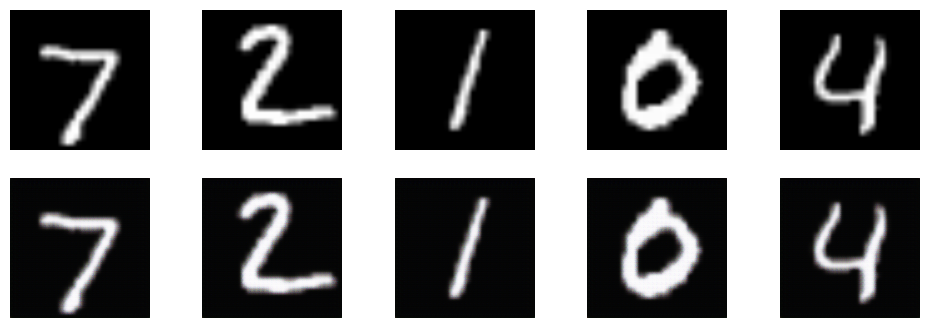

In [230]:
# --------------------
# Generate & Show Images
# --------------------
def show_results(model, loader):
    model.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs[:5].to(device)

    with torch.no_grad():
        gen = model(imgs)

    imgs = (imgs.cpu() + 1) / 2
    gen = (gen.cpu() + 1) / 2

    plt.figure(figsize=(12,4))
    for i in range(5):
        plt.subplot(2,5,i+1)
        plt.imshow(imgs[i].permute(1,2,0))
        plt.axis("off")
        plt.subplot(2,5,i+6)
        plt.imshow(gen[i].permute(1,2,0))
        plt.axis("off")
    plt.show()

show_results(G, val_loader)


DenseBlock torch.Size([5, 3, 256, 256])
EncoderBlock torch.Size([5, 64, 128, 128])
DenseBlock torch.Size([5, 64, 128, 128])
EncoderBlock torch.Size([5, 128, 64, 64])
DenseBlock torch.Size([5, 128, 64, 64])
EncoderBlock torch.Size([5, 256, 32, 32])
DenseBlock torch.Size([5, 256, 32, 32])
EncoderBlock torch.Size([5, 512, 16, 16])
DenseBlock torch.Size([5, 512, 16, 16])
EncoderBlock torch.Size([5, 512, 8, 8])
DenseBlock torch.Size([5, 512, 8, 8])
EncoderBlock torch.Size([5, 512, 4, 4])
DenseBlock torch.Size([5, 512, 4, 4])
EncoderBlock torch.Size([5, 512, 2, 2])
DenseBlock torch.Size([5, 512, 4, 4])
DecoderBlock torch.Size([5, 512, 4, 4])
DenseBlock torch.Size([5, 512, 8, 8])
DecoderBlock torch.Size([5, 512, 8, 8])
DenseBlock torch.Size([5, 512, 16, 16])
DecoderBlock torch.Size([5, 512, 16, 16])
DenseBlock torch.Size([5, 256, 32, 32])
DecoderBlock torch.Size([5, 256, 32, 32])
DenseBlock torch.Size([5, 128, 64, 64])
DecoderBlock torch.Size([5, 128, 64, 64])
DenseBlock torch.Size([5, 64, 12

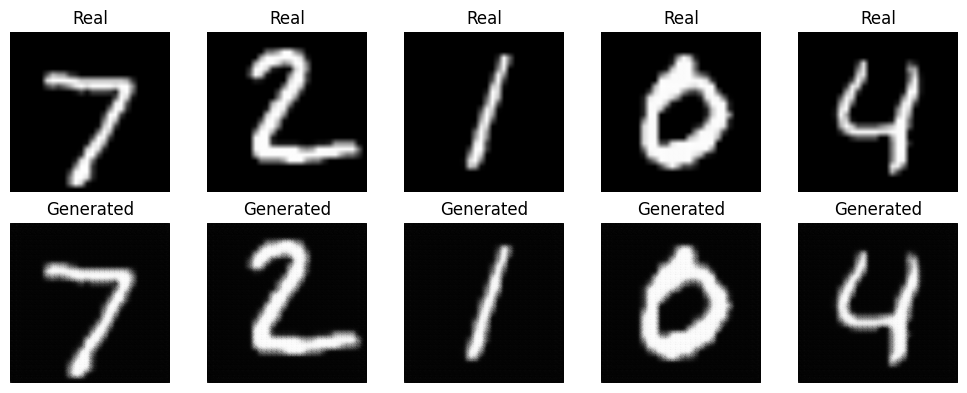

SSIM scores: [np.float64(0.35115608186858893), np.float64(0.3999607014568746), np.float64(0.294305169903636), np.float64(0.41337860118243097), np.float64(0.3620662850856483)]
Average SSIM: 0.3641733678994357


In [231]:
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import numpy as np
import torch

def generate_and_evaluate_ssim(generator, dataloader, device, num_images=5):
    """
    Generate images from a UNet-like generator and evaluate SSIM.
    No latent noise vector is used, input is real images.
    """
    generator.eval()

    # Get a batch of real images
    real_imgs, _ = next(iter(dataloader))
    real_imgs = real_imgs[:num_images].to(device)

    # Generate images using the generator (image-to-image)
    with torch.no_grad():
        gen_imgs = generator(real_imgs)

    # Convert tensors to numpy
    real_imgs = real_imgs.cpu().numpy()
    gen_imgs  = gen_imgs.cpu().numpy()

    # UNet images are [C,H,W]; convert to [H,W] grayscale if C=1 or pick one channel if C>1
    if real_imgs.shape[1] > 1:
        real_imgs = real_imgs[:,0,:,:]  # take first channel
        gen_imgs  = gen_imgs[:,0,:,:]

    # Denormalize from [-1,1] to [0,1]
    real_imgs = (real_imgs + 1) / 2
    gen_imgs  = (gen_imgs + 1) / 2

    ssim_scores = []

    # Plot real vs generated
    plt.figure(figsize=(10,4))
    for i in range(num_images):
        plt.subplot(2, num_images, i+1)
        plt.imshow(real_imgs[i], cmap="gray")
        plt.title("Real")
        plt.axis("off")

        plt.subplot(2, num_images, i+1+num_images)
        plt.imshow(gen_imgs[i], cmap="gray")
        plt.title("Generated")
        plt.axis("off")

        # Compute SSIM
        score = ssim(real_imgs[i], gen_imgs[i], data_range=1.0)
        ssim_scores.append(score)

    plt.tight_layout()
    plt.show()

    print("SSIM scores:", ssim_scores)
    print("Average SSIM:", np.mean(ssim_scores))


# Example usage
generate_and_evaluate_ssim(G, val_loader, device, num_images=5)


In [232]:
# --------------------
# NMSE: Normalized MSE ↓
# --------------------
def NMSE(x, y):
    x = (x + 1) / 2
    y = (y + 1) / 2
    # x, y: [B, C, H, W], values [0,1]
    mse = F.mse_loss(x, y, reduction='none')
    nmse = mse.view(mse.size(0), -1).sum(dim=1) / (y.view(y.size(0), -1)**2).sum(dim=1)
    return nmse.mean().item()


real_imgs, _ = next(iter(train_loader))
real_imgs = real_imgs[:1].to(device)
gen_imgs = G(real_imgs)
print(real_imgs[:,1:10])
print(real_imgs[:,1:10])

DenseBlock torch.Size([1, 3, 256, 256])
EncoderBlock torch.Size([1, 64, 128, 128])
DenseBlock torch.Size([1, 64, 128, 128])
EncoderBlock torch.Size([1, 128, 64, 64])
DenseBlock torch.Size([1, 128, 64, 64])
EncoderBlock torch.Size([1, 256, 32, 32])
DenseBlock torch.Size([1, 256, 32, 32])
EncoderBlock torch.Size([1, 512, 16, 16])
DenseBlock torch.Size([1, 512, 16, 16])
EncoderBlock torch.Size([1, 512, 8, 8])
DenseBlock torch.Size([1, 512, 8, 8])
EncoderBlock torch.Size([1, 512, 4, 4])
DenseBlock torch.Size([1, 512, 4, 4])
EncoderBlock torch.Size([1, 512, 2, 2])
DenseBlock torch.Size([1, 512, 4, 4])
DecoderBlock torch.Size([1, 512, 4, 4])
DenseBlock torch.Size([1, 512, 8, 8])
DecoderBlock torch.Size([1, 512, 8, 8])
DenseBlock torch.Size([1, 512, 16, 16])
DecoderBlock torch.Size([1, 512, 16, 16])
DenseBlock torch.Size([1, 256, 32, 32])
DecoderBlock torch.Size([1, 256, 32, 32])
DenseBlock torch.Size([1, 128, 64, 64])
DecoderBlock torch.Size([1, 128, 64, 64])
DenseBlock torch.Size([1, 64, 12

In [233]:
# --------------------
# NMAE: Normalized MAE ↑
# --------------------
def NMAE(x, y, eps=1e-8):
    """
    NMAE (↓)
    x, y: [B, C, H, W] in [-1, 1]
    """
    # map to [0,1]
    x = (x + 1) / 2
    y = (y + 1) / 2

    num = torch.abs(x - y).view(x.size(0), -1).sum(dim=1)
    den = torch.abs(y).view(y.size(0), -1).sum(dim=1) + eps

    return (num / den).mean().item()

In [234]:
# --------------------
# PSNR ↑
# --------------------
def PSNR(x, y, max_val=1.0):
     # map to [0,1]
    x = (x + 1) / 2
    y = (y + 1) / 2
    x_np = x.detach().cpu().numpy()
    y_np = y.detach().cpu().numpy()
    psnr_vals = [psnr(y_np[i], x_np[i], data_range=max_val) for i in range(x_np.shape[0])]
    return np.mean(psnr_vals)

In [235]:
# --------------------
# SSIM ↑
# --------------------
def SSIM(x, y):
     # map to [0,1]
    x = (x + 1) / 2
    y = (y + 1) / 2
    x_np = x.detach().cpu().numpy()
    y_np = y.detach().cpu().numpy()
    ssim_vals = [ssim(y_np[i].transpose(1,2,0), x_np[i].transpose(1,2,0), multichannel=True, data_range=1.0) for i in range(x_np.shape[0])]
    return np.mean(ssim_vals)

In [236]:
# --------------------
# MS-SSIM ↓ (1 - ms-ssim)
# --------------------
def MS_SSIM(x, y):
     # map to [0,1]
    x = (x + 1) / 2
    y = (y + 1) / 2
    return 1 - ms_ssim(x, y, data_range=1.0, size_average=True).item()

In [237]:
# --------------------
# LPIPS ↓
# --------------------

lpips_alex = lpips.LPIPS(net='alex').to(device)
def LPIPS(x, y):
    return lpips_alex(x*2-1, y*2-1).mean().item()  # scale to [-1,1]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: c:\Users\fhabi\AppData\Local\Programs\Python\Python310\lib\site-packages\lpips\weights\v0.1\alex.pth


In [238]:
# --------------------
# FID ↓
# --------------------
# Matrix square root using SVD
def sqrtm_torch(A):
    U, S, Vh = torch.linalg.svd(A)
    sqrt_S = torch.sqrt(S)
    return (U * sqrt_S) @ Vh

# FID function
def FID(x, y, device='cpu'):
    x_rgb = x.repeat(1, 3, 1, 1)
    y_rgb = y.repeat(1, 3, 1, 1)
    """
    Compute Fréchet Inception Distance (FID) between two sets of images x and y.
    x, y : torch.Tensor, shape [B, C, H, W], in range [-1, 1] or [0, 1]
    """
    # Load InceptionV3
    inception = inception_v3(pretrained=True, transform_input=False).to(device)
    inception.eval()
    inception.fc = nn.Identity()
    pool = AdaptiveAvgPool2d((1, 1))

    def get_features(imgs):
        imgs = F.interpolate(imgs, size=(299, 299), mode='bilinear', align_corners=False)
        with torch.no_grad():
            feats = inception(imgs)
            feats = pool(feats).view(feats.size(0), -1)  # [B, 2048]
        return feats

    feats_x = get_features(x.to(device))
    feats_y = get_features(y.to(device))

    mu_x, sigma_x = feats_x.mean(0), torch.cov(feats_x.T)
    mu_y, sigma_y = feats_y.mean(0), torch.cov(feats_y.T)

    diff = mu_x - mu_y
    covmean = sqrtm_torch(sigma_x @ sigma_y + 1e-6 * torch.eye(sigma_x.shape[0], device=device))

    fid_score = (diff @ diff + torch.trace(sigma_x + sigma_y - 2 * covmean)).item()
    return fid_score

In [239]:
print('NMSE(↓):',NMSE(real_imgs, gen_imgs))
print('NMAE(↓):',NMAE(real_imgs, gen_imgs))
print('PSNR(↑):',PSNR(real_imgs, gen_imgs))
#print('SSIM(↑):',SSIM(real_imgs, gen_imgs))
print('MS_SSIM(↑):',MS_SSIM(real_imgs, gen_imgs))
#print('FID(↓):',FID(real_imgs, gen_imgs))
print('LPIPS(↓):',LPIPS(real_imgs, gen_imgs))


NMSE(↓): 0.0226888470351696
NMAE(↓): 0.30993103981018066
PSNR(↑): 29.944099771965746
MS_SSIM(↑): 0.01978522539138794
LPIPS(↓): 0.07021071761846542
